Минькин Александр Дмитриевич - ИКБО-25-22



<h1> Практическая работа №6


<h1> Задача кластеризации

1. Найти данные для кластеризации. Данные в группе не должны
повторяться. Если признаки в данных имеют очень сильно разные
масштабы, то необходимо данные предварительно нормализовать.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_population2023.csv to data_population2023.csv


2. Провести кластеризацию данных с помощью алгоритма k-means.
Использовать «правило локтя» и коэффициент силуэта для поиска
оптимального количества кластеров.

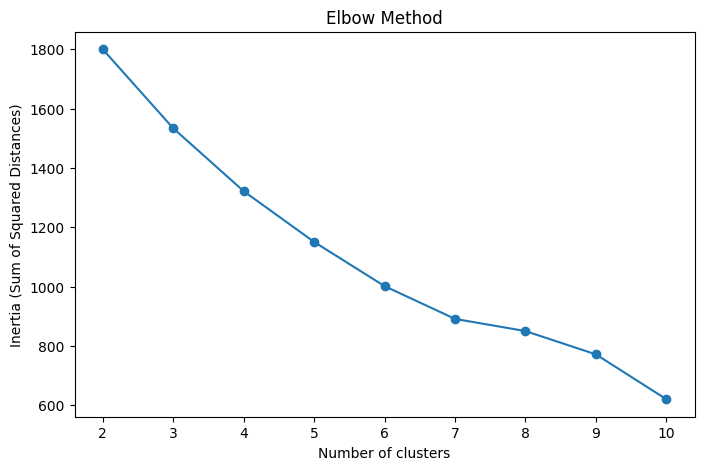

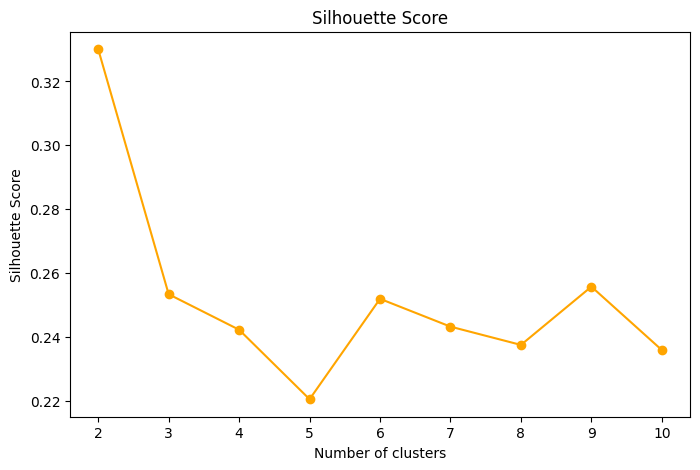

Оптимальное число кластеров: 2


,sr.no.,province,division,district,households,population_2023,average_household_size,population_2017,growth_rate,area(km²),...,secondary_boys_schools,secondary_girls_schools,high_boys_schools,high_girls_schools,Intermediate_boys_schools,Intermediate_girls_schools,total_boys_schools,total_girls_schools,total_schools,cluster
0,1,Balochistan,Kalat,Awaran,27808,178958,6.44,121821,6.64,29510,...,24,13,29,10,2,2,249,132,381,0
1,2,Balochistan,Kalat,Kalat,33415,272506,8.16,211201,4.35,6622,...,23,18,27,17,1,1,269,120,389,0
2,3,Balochistan,Kalat,Khuzdar,161594,997214,6.17,798896,3.78,35380,...,45,46,32,21,6,1,569,245,814,0
3,4,Balochistan,Kalat,Lasbela,115635,680977,5.89,576271,2.83,15153,...,46,29,27,11,4,4,507,168,675,0
4,5,Balochistan,Kalat,Mastung,43736,313271,7.16,265676,2.79,5896,...,24,31,18,18,2,0,268,143,411,0


In [2]:
# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Загружаем данные
data = pd.read_csv("data_population2023.csv")

# Используем все числовые столбцы для кластеризации
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
X = data[numerical_cols]

# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Поиск оптимального числа кластеров с помощью "правила локтя"
inertia = []
K_range = range(2, 11)  # Проверим от 2 до 10 кластеров
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Визуализация правила локтя
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.show()

# Расчет коэффициента силуэта для каждого числа кластеров
silhouette_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Визуализация коэффициента силуэта
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

# Выбираем оптимальное число кластеров по максимальному силуэту
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Оптимальное число кластеров: {optimal_k}")

# Финальная кластеризация с оптимальным числом кластеров
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['cluster'] = final_kmeans.fit_predict(X_scaled)

# Просмотр первых строк с кластерами
data.head()


3. Провести кластеризацию данных с помощью алгоритма иерархической
кластеризации.

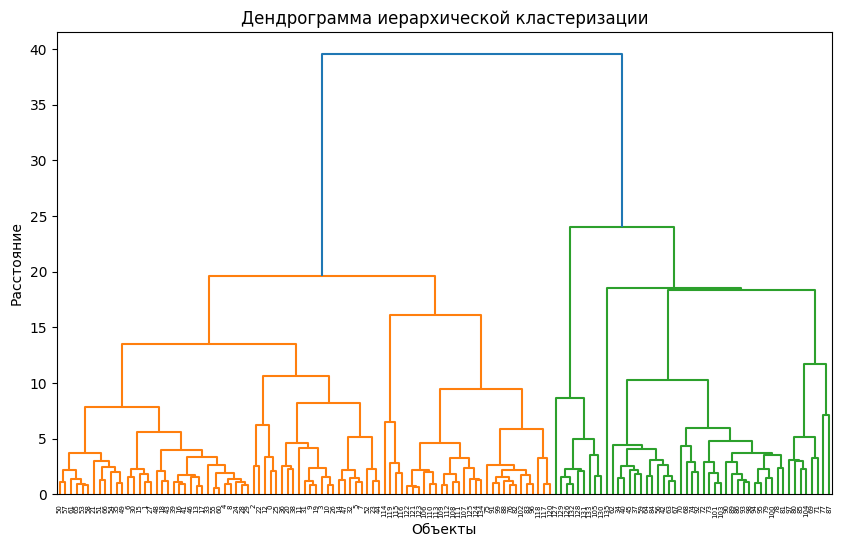

,sr.no.,province,division,district,households,population_2023,average_household_size,population_2017,growth_rate,area(km²),...,secondary_boys_schools,secondary_girls_schools,high_boys_schools,high_girls_schools,Intermediate_boys_schools,Intermediate_girls_schools,total_boys_schools,total_girls_schools,total_schools,hierarchical_cluster
0,1,Balochistan,Kalat,Awaran,27808,178958,6.44,121821,6.64,29510,...,24,13,29,10,2,2,249,132,381,1
1,2,Balochistan,Kalat,Kalat,33415,272506,8.16,211201,4.35,6622,...,23,18,27,17,1,1,269,120,389,1
2,3,Balochistan,Kalat,Khuzdar,161594,997214,6.17,798896,3.78,35380,...,45,46,32,21,6,1,569,245,814,1
3,4,Balochistan,Kalat,Lasbela,115635,680977,5.89,576271,2.83,15153,...,46,29,27,11,4,4,507,168,675,1
4,5,Balochistan,Kalat,Mastung,43736,313271,7.16,265676,2.79,5896,...,24,31,18,18,2,0,268,143,411,1


In [3]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Загружаем данные
data = pd.read_csv("data_population2023.csv")

# Используем числовые столбцы
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
X = data[numerical_cols]

# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Построение иерархической кластеризации
# Используем метод 'ward' (минимизация дисперсии)
linked = linkage(X_scaled, method='ward')

# Визуализация дендрограммы
plt.figure(figsize=(10, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='ascending',
           show_leaf_counts=True)
plt.title("Дендрограмма иерархической кластеризации")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")
plt.show()

# Определение кластеров
# Здесь можно задать число кластеров, например 3
num_clusters = 3
clusters = fcluster(linked, num_clusters, criterion='maxclust')

# Добавляем столбец с кластерами в DataFrame
data['hierarchical_cluster'] = clusters

# Просмотр первых строк с кластерами
data.head()


4. Провести кластеризацию данных с помощью алгоритма DBSCAN.

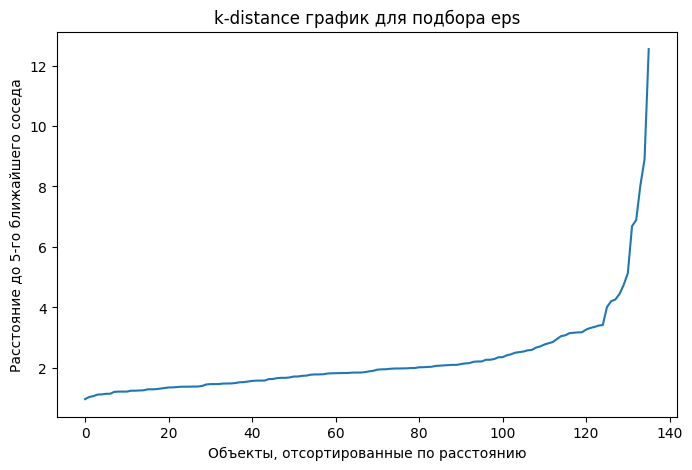

Количество кластеров: 2
Количество шумовых точек: 82


,sr.no.,province,division,district,households,population_2023,average_household_size,population_2017,growth_rate,area(km²),...,secondary_boys_schools,secondary_girls_schools,high_boys_schools,high_girls_schools,Intermediate_boys_schools,Intermediate_girls_schools,total_boys_schools,total_girls_schools,total_schools,dbscan_cluster
0,1,Balochistan,Kalat,Awaran,27808,178958,6.44,121821,6.64,29510,...,24,13,29,10,2,2,249,132,381,-1
1,2,Balochistan,Kalat,Kalat,33415,272506,8.16,211201,4.35,6622,...,23,18,27,17,1,1,269,120,389,0
2,3,Balochistan,Kalat,Khuzdar,161594,997214,6.17,798896,3.78,35380,...,45,46,32,21,6,1,569,245,814,-1
3,4,Balochistan,Kalat,Lasbela,115635,680977,5.89,576271,2.83,15153,...,46,29,27,11,4,4,507,168,675,0
4,5,Balochistan,Kalat,Mastung,43736,313271,7.16,265676,2.79,5896,...,24,31,18,18,2,0,268,143,411,0


In [4]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Загружаем данные
data = pd.read_csv("data_population2023.csv")

# Выбираем числовые столбцы
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
X = data[numerical_cols]

# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Подбор eps с помощью графика расстояний до k ближайшего соседа
neighbors = NearestNeighbors(n_neighbors=5)  # k = min_samples - 1, обычно 4
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])  # 4-й сосед
plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("k-distance график для подбора eps")
plt.xlabel("Объекты, отсортированные по расстоянию")
plt.ylabel("Расстояние до 5-го ближайшего соседа")
plt.show()

# Применение DBSCAN
# eps нужно подобрать визуально из графика k-distance
dbscan = DBSCAN(eps=1.5, min_samples=5)  # примерные значения
dbscan_labels = dbscan.fit_predict(X_scaled)

# Добавляем столбец с кластерами
data['dbscan_cluster'] = dbscan_labels

# Выводим количество кластеров и количество шумовых точек
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise}")

# Просмотр первых строк с кластерами
data.head()


5. Визуализировать кластеризованные данные с помощью t-SNE или
UMAP, если необходимо. Если данные трехмерные, то можно
использовать трехмерный точечный график.

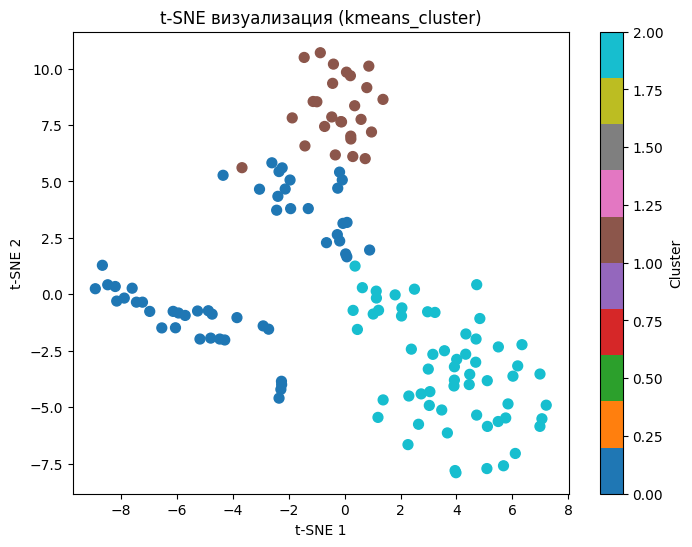

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


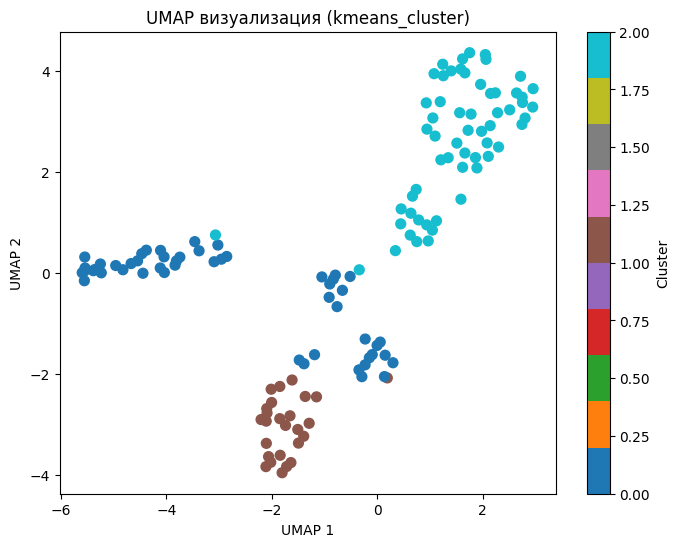

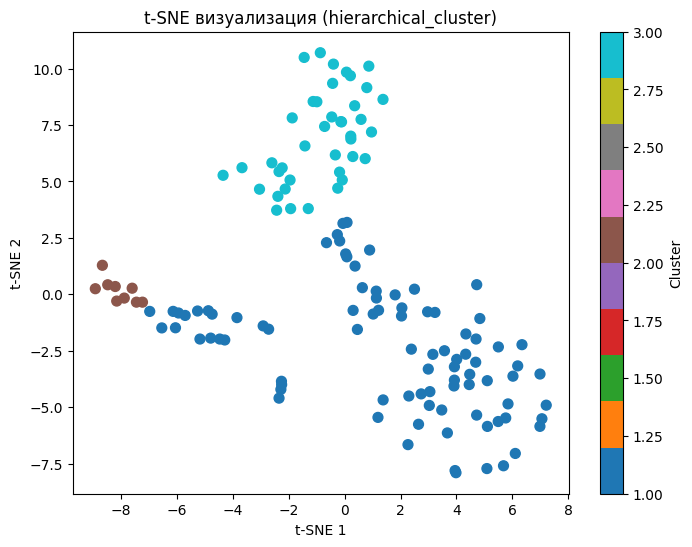

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


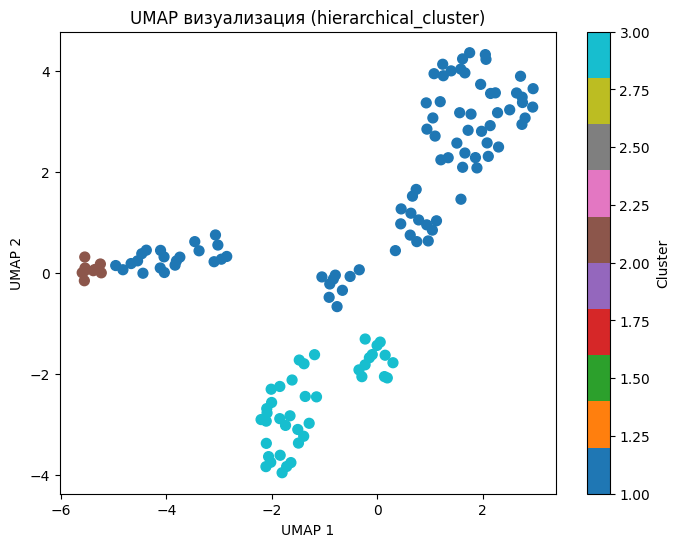

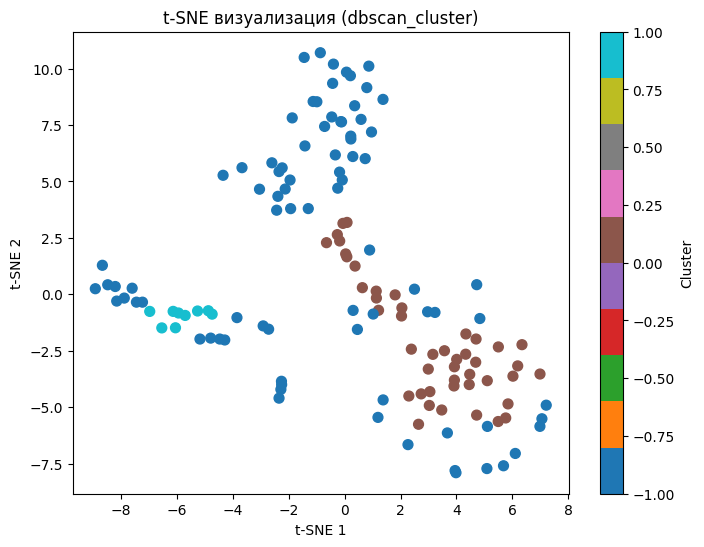

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


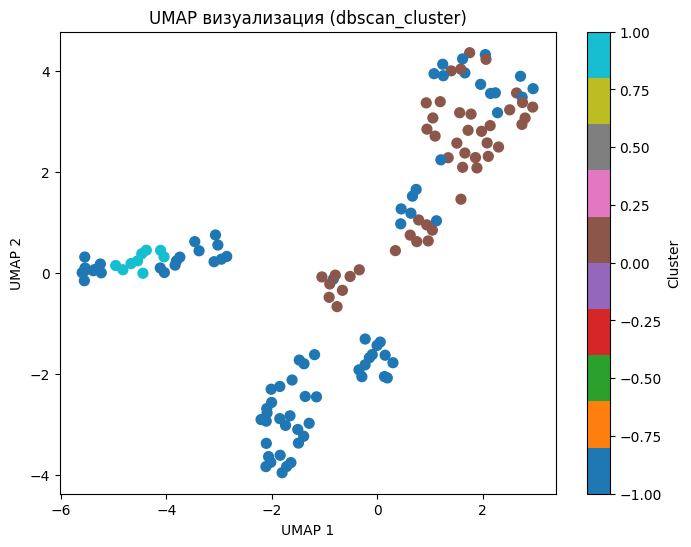

,sr.no.,province,division,district,households,population_2023,average_household_size,population_2017,growth_rate,area(km²),...,high_boys_schools,high_girls_schools,Intermediate_boys_schools,Intermediate_girls_schools,total_boys_schools,total_girls_schools,total_schools,kmeans_cluster,hierarchical_cluster,dbscan_cluster
0,1,Balochistan,Kalat,Awaran,27808,178958,6.44,121821,6.64,29510,...,29,10,2,2,249,132,381,2,1,-1
1,2,Balochistan,Kalat,Kalat,33415,272506,8.16,211201,4.35,6622,...,27,17,1,1,269,120,389,2,1,0
2,3,Balochistan,Kalat,Khuzdar,161594,997214,6.17,798896,3.78,35380,...,32,21,6,1,569,245,814,2,1,-1
3,4,Balochistan,Kalat,Lasbela,115635,680977,5.89,576271,2.83,15153,...,27,11,4,4,507,168,675,2,1,0
4,5,Balochistan,Kalat,Mastung,43736,313271,7.16,265676,2.79,5896,...,18,18,2,0,268,143,411,2,1,0


In [7]:
# ================================
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.manifold import TSNE
import umap
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# ================================
# 1. Загрузка данных
data = pd.read_csv("data_population2023.csv")
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
X = data[numerical_cols]

# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 2. K-means кластеризация
optimal_k = 3  # пример, можно изменить после анализа локтя/силуэта
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# ================================
# 3. Иерархическая кластеризация
linked = linkage(X_scaled, method='ward')
num_clusters = 3  # пример, можно подбирать по дендрограмме
data['hierarchical_cluster'] = fcluster(linked, num_clusters, criterion='maxclust')

# ================================
# 4. DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  # eps можно подбирать через k-distance график
data['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# ================================
# 5. Визуализация кластеров через t-SNE и UMAP
def visualize_clusters(X_scaled, df, cluster_col, method='t-SNE', dims=2):
    if method == 't-SNE':
        reducer = TSNE(n_components=dims, random_state=42)
    elif method == 'UMAP':
        reducer = umap.UMAP(n_components=dims, random_state=42)
    else:
        raise ValueError("method must be 't-SNE' or 'UMAP'")

    X_reduced = reducer.fit_transform(X_scaled)

    if dims == 2:
        plt.figure(figsize=(8,6))
        plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df[cluster_col], cmap='tab10', s=50)
        plt.title(f"{method} визуализация ({cluster_col})")
        plt.xlabel(f"{method} 1")
        plt.ylabel(f"{method} 2")
        plt.colorbar(label='Cluster')
        plt.show()
    elif dims == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(X_reduced[:,0], X_reduced[:,1], X_reduced[:,2],
                             c=df[cluster_col], cmap='tab10', s=50)
        ax.set_title(f"3D {method} визуализация ({cluster_col})")
        ax.set_xlabel(f"{method} 1")
        ax.set_ylabel(f"{method} 2")
        ax.set_zlabel(f"{method} 3")
        fig.colorbar(scatter, ax=ax, label='Cluster')
        plt.show()

# Визуализируем все кластеризации (2D)
for col in ['kmeans_cluster', 'hierarchical_cluster', 'dbscan_cluster']:
    visualize_clusters(X_scaled, data, col, method='t-SNE', dims=2)
    visualize_clusters(X_scaled, data, col, method='UMAP', dims=2)

# ================================
# Просмотр первых строк с кластерами
data.head()


**Вывод:**

В ходе выполнения заданий 2–5 была проведена комплексная кластеризация данных с использованием различных алгоритмов: K-means, иерархической кластеризации и DBSCAN, с последующим анализом качества кластеризации через правило локтя, коэффициент силуэта и визуальный подбор параметров. K-means позволил выявить оптимальное число кластеров на основе максимального силуэта, и объекты были распределены по четко различимым группам. Иерархическая кластеризация обеспечила наглядное представление структуры данных через дендрограмму и позволила формировать кластеры на разных уровнях разбиения. DBSCAN выявил как плотные кластеры, так и шумовые точки, что особенно полезно при наличии выбросов. Для визуализации результатов была применена методика снижения размерности (t-SNE и UMAP), которая позволила на двумерной или трехмерной плоскости наглядно оценить распределение кластеров и взаимное расстояние между ними, подтвердив внутреннюю структуру и качество выделенных групп.